# 03 Funnels

## Goal

Measure view to cart to purchase progression and identify where customer intent is lost.

## Setup

Connect to the local DuckDB database created by the transformation pipeline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df, read_sql

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Concept

A funnel measures progression through steps. Here the core product funnel is View -> Cart -> Purchase. We will be explicit that this can be user-based, session-based, or product-based.

In [2]:
user_funnel = query_df(con, read_sql("analysis/funnel.sql"))
user_funnel

,viewers,cart_users,purchasers,view_to_cart_rate,cart_to_purchase_rate
0,5316128,1054133,697470,0.1983,0.6617


In [3]:
category_funnel = query_df(con, """
SELECT
    category_code,
    SUM(viewing_users) AS viewers,
    SUM(cart_users) AS cart_users,
    SUM(purchasing_users) AS purchasers,
    SUM(cart_users) * 1.0 / NULLIF(SUM(viewing_users), 0) AS view_to_cart_rate,
    SUM(purchasing_users) * 1.0 / NULLIF(SUM(cart_users), 0) AS cart_to_purchase_rate
FROM analytics.mart_product_funnel
GROUP BY 1
HAVING viewers >= 10000
ORDER BY viewers DESC
LIMIT 25
""")
category_funnel.head(10)

,category_code,viewers,cart_users,purchasers,view_to_cart_rate,cart_to_purchase_rate
0,unknown,20093866.0000,539607.0000,334402.0000,0.0269,0.6197
1,electronics.smartphone,12208335.0000,827547.0000,498478.0000,0.0678,0.6024
2,apparel.shoes,1821593.0000,25125.0000,12166.0000,0.0138,0.4842
3,electronics.clocks,1783919.0000,49803.0000,30636.0000,0.0279,0.6151
4,computers.notebook,1565687.0000,43205.0000,26401.0000,0.0276,0.6111
5,electronics.video.tv,1442131.0000,77504.0000,41201.0000,0.0537,0.5316
6,electronics.audio.headphone,1226858.0000,84221.0000,48574.0000,0.0686,0.5767
7,appliances.kitchen.refrigerators,1140749.0000,36059.0000,20160.0000,0.0316,0.5591
8,appliances.environment.vacuum,1042450.0000,45493.0000,25991.0000,0.0436,0.5713
9,appliances.kitchen.washer,1006443.0000,47736.0000,28656.0000,0.0474,0.6003


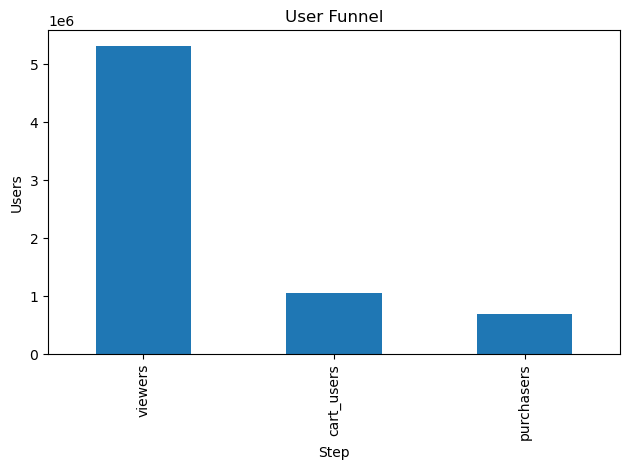

In [4]:
plot_data = user_funnel[["viewers", "cart_users", "purchasers"]].T.reset_index()
plot_data.columns = ["step", "users"]
ax = plot_data.plot(kind="bar", x="step", y="users", legend=False, title="User Funnel")
ax.set_xlabel("Step")
ax.set_ylabel("Users")
plt.tight_layout()

## Session Funnel Caveat

This notebook focuses on the **user-level funnel** and **category/product funnel** because the compact pipeline does not materialize a full session-level fact table by default.

Session-level funnel analysis is still possible later, but it should flag or exclude the known multi-user session issue documented in `docs/data_quality_summary.md`.

## Takeaways

- The user-level funnel shows **5,316,128 viewers**, **1,054,133 cart users**, and **697,470 purchasers**.
- The largest drop-off happens before cart: only **19.83%** of viewers become cart users. This suggests the biggest product opportunity is likely in product discovery, product detail pages, pricing clarity, merchandising, or recommendation quality.
- Once users reach cart, the funnel is much stronger: **66.17%** of cart users become purchasers. Checkout still matters, but the user-level data suggests pre-cart conversion is the larger opportunity.
- Category performance varies meaningfully. For example, `electronics.smartphone` has a much higher view-to-cart rate (**6.78%**) than `unknown` category traffic (**2.69%**) and `apparel.shoes` (**1.38%**).
- The large `unknown` category group has the most viewers, so missing category labels are not just a data-quality footnote. They limit how precisely Product and Merchandising can diagnose funnel drop-offs.
- Future recommendations should prioritize categories with high traffic but low view-to-cart conversion, then investigate whether the issue is product relevance, pricing, availability, product-page quality, or category labeling.

Overall, the funnel indicates that the main growth lever is moving more viewers into cart, not only improving checkout completion.